In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

In [34]:
df = pd.read_csv("thyroid_dataset.csv")

In [35]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [36]:
df.describe()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
count,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000
mean,0.595098,0.307548,0.134615,0.015616,0.013158,0.038317,0.011278,0.014315,0.016773,0.062753,0.069404,0.013013,0.008531,0.025448,0.000145,0.049740,1.603466,11.772446,94.253834,88.270139,95.257058
std,6.189326,0.461512,0.341337,0.123993,0.113959,0.191974,0.105606,0.118793,0.128428,0.242536,0.254159,0.113339,0.091975,0.157494,0.012025,0.217422,14.047218,11.836250,50.555642,33.909845,55.031137
min,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000500,0.002500,0.050000,0.002400
25%,0.370000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000680,0.020100,77.000000,83.000000,81.000000
50%,0.540000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001700,13.000000,101.000000,96.000000,105.000000
75%,0.670000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002700,22.000000,123.000000,104.000000,125.000000
max,515.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,494.000000,95.000000,395.000000,233.000000,642.000000


In [37]:
df.shape

(6916, 22)

In [38]:
X = df.drop("Outlier_label", axis=1)
y = df["Outlier_label"]

In [39]:
X.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
X_scaled

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [42]:
clf = IsolationForest(
    n_estimators = 200,
    contamination=0.036,
    random_state=42
)

labels = clf.fit_predict(X_scaled)

In [43]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 1.0, 'PC1 vs PC2')

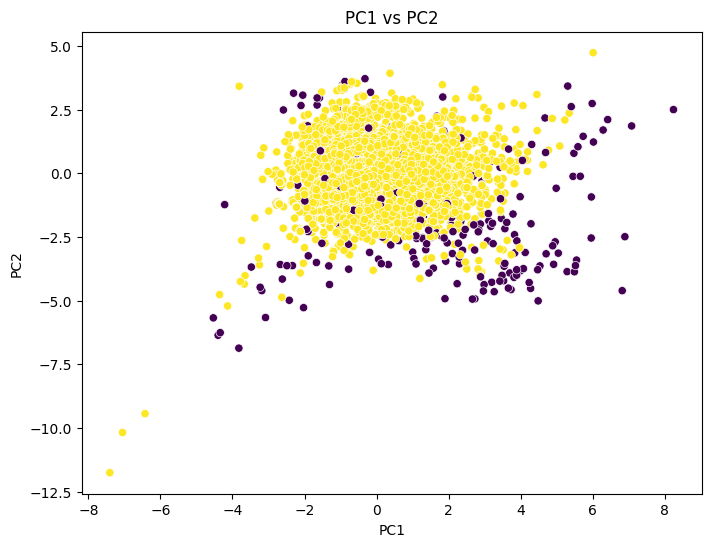

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x = X_pca[:,0],
    y = X_pca[:,1],
    c=labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2")

In [45]:
n_outliers =  np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("Outlers", n_outliers)
print("Normal", n_normal)

Outlers 249
Normal 6667


In [51]:
neighnors = LocalOutlierFactor(contamination=0.036)

labels = neighnors.fit_predict(X_scaled)

Text(0.5, 1.0, 'PC1 vs PC2')

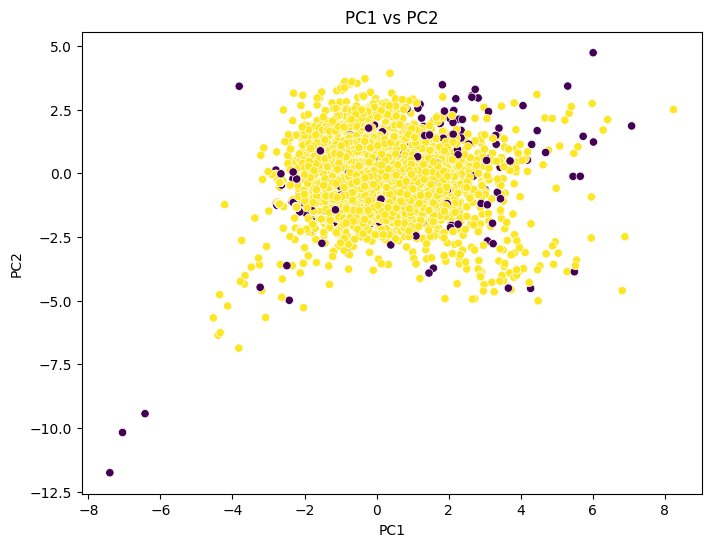

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x = X_pca[:,0],
    y = X_pca[:,1],
    c=labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2")

In [53]:
n_outliers =  np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("Outlers", n_outliers)
print("Normal", n_normal)

Outlers 249
Normal 6667
